In [1]:
import xarray as xr
import geopandas as gpd
import rioxarray  

RUTA_SHAPEFILE_MEXICO = "../data/001_raw/INEGI/00ent.shp"
RUTA_NETCDF_PRUEBA = "../data/001_raw/ECMWF_utci_2022_mexico_anual.nc"

In [2]:
def load_region_geometry(shapefile_path, dissolve=True, crs="EPSG:4326"):
    """
    Carga un shapefile de una región (país, estado, lo que sea) y lo regresa
    como un solo polígono (si dissolve=True) en el CRS pedido.
    """
    region = gpd.read_file(shapefile_path)
    region = region.to_crs(crs)
    if dissolve:
        region = region.dissolve()
    return region

<Axes: >

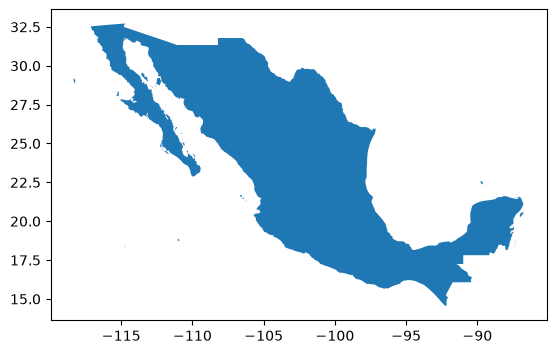

In [3]:
mexico = load_region_geometry(RUTA_SHAPEFILE_MEXICO)
mexico.plot()

In [4]:
def prepare_dataset(ds, x_dim="lon", y_dim="lat", crs="EPSG:4326"):
    """
    Deja el dataset listo para recortar
    """
    ds = ds.rio.set_spatial_dims(x_dim=x_dim, y_dim=y_dim)
    ds = ds.rio.write_crs(crs)
    return ds

In [5]:
ds = xr.open_dataset(RUTA_NETCDF_PRUEBA)
ds_listo = prepare_dataset(ds)

print("x_dim:", ds_listo.rio.x_dim)
print("y_dim:", ds_listo.rio.y_dim)

x_dim: lon
y_dim: lat


In [6]:
def clip_to_region(ds, region_gdf, drop=False):
    """
    Recorta un dataset (ya preparado con prepare_dataset) al polígono de
    region_gdf. drop=False mantiene la grilla original y pone NaN fuera de
    la región"""
    return ds.rio.clip(region_gdf.geometry, region_gdf.crs, drop=drop)

In [7]:
def kelvin_a_celsius(dataset_o_variable):
    """
    Convierte de Kelvin a Celsius restando 273.15.
    Funciona igual si le pasas un Dataset completo o solo un DataArray/variable.
    """
    return dataset_o_variable - 273.15

In [8]:
def mask_netcdf(
    netcdf_path,
    shapefile_path,
    output_path,
    variable="utci",
    x_dim="lon",
    y_dim="lat",
    crs="EPSG:4326",
    drop=False,
):
    """
    Recorta un NetCDF a una región (usando su shapefile), convierte esa
    variable de Kelvin a Celsius, y guarda el resultado en un nuevo .nc.

    El archivo que se guarda contiene únicamente los puntos dentro de la
    región (el resto queda como NaN, o se recorta del todo si drop=True),
    ya en Celsius.
    """
    with xr.open_dataset(netcdf_path) as ds:
        ds = prepare_dataset(ds, x_dim=x_dim, y_dim=y_dim, crs=crs)
        region = load_region_geometry(shapefile_path, crs=crs)
        ds_region = clip_to_region(ds, region, drop=drop)
        ds_region = ds_region.load()  # a memoria antes de cerrar el archivo de entrada

    # Convierte DESPUÉS de enmascarar: restarle 273.15 a los NaN de fuera de
    # la región sigue dando NaN, así que el orden no cambia el resultado —
    # pero mantenerlo así dentro de la función es más fácil de leer:
    # "primero recorto, luego convierto lo que quedó".
    ds_region[variable] = kelvin_a_celsius(ds_region[variable])

    ds_region.to_netcdf(output_path)
    return ds_region

In [9]:
ds_mexico_celsius = mask_netcdf(
    netcdf_path=RUTA_NETCDF_PRUEBA,
    shapefile_path=RUTA_SHAPEFILE_MEXICO,
    output_path="../data/2022_mexico_celsius.nc",
)

utci_t0 = ds_mexico_celsius["utci"].isel(time=0)
print("Celdas con dato:", int(utci_t0.notnull().sum()), "/", utci_t0.size)
print("Rango (Celsius):", float(utci_t0.min()), "a", float(utci_t0.max()))

Celdas con dato: 2798 / 10241
Rango (Celsius): -12.486114501953125 a 32.8211669921875


In [10]:
recorte = "../data/2022_mexico_celsius.nc"

map_mex = xr.open_dataset(recorte)

In [11]:
map_mex

<xarray.Dataset> Size: 359MB
Dimensions:      (time: 8760, lat: 77, lon: 133)
Coordinates:
  * time         (time) datetime64[ns] 70kB 2022-01-01 ... 2022-12-31T23:00:00
  * lat          (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.5 14.25 14.0
  * lon          (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.5 -86.25 -86.0
    spatial_ref  int64 8B ...
Data variables:
    utci         (time, lat, lon) float32 359MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.8 (https://...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.8 (https://...
    cdo_openmp_thread_number:  8
    history:                   Mon Apr  4 07:54:18 2022: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.7.8 (Homepage = htt...